In [8]:
import os
from dotenv import load_dotenv
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

In [9]:
import pandas as pd

train = pd.read_csv("data/train.csv")

train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent
from langchain_openai import ChatOpenAI


ModuleNotFoundError: No module named 'matplotlib'

In [16]:
llm_model = ChatOpenAI(
    model="gpt-3.5-turbo-0125",  # OpenAI GPT-4o 모델 사용
    temperature=0,
    openai_api_key=OPENAI_API_KEY,
)

agent_executor = create_pandas_dataframe_agent(
    llm_model,
    train,
    agent_type="openai-tools", # OpenAI Tools 에이전트 사용
    verbose=True, # 로그 출력
    return_intermediate_steps=False,
    allow_dangerous_code=True, # 위험한 코드 실행 허용 (필수)
)

In [17]:
agent_executor.invoke("행과 열의 수를 알려줘") # 행과 열의 수를 묻는 질문



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': 'df.shape[0]'}`


1460
Invoking: `python_repl_ast` with `{'query': 'df.shape[1]'}`


81이 데이터프레임에는 1460개의 행과 81개의 열이 있습니다.

> Finished chain.


{'input': '행과 열의 수를 알려줘', 'output': '이 데이터프레임에는 1460개의 행과 81개의 열이 있습니다.'}

In [22]:
# matplotlib 라이브러리 설치
%pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------- -------------------- 3.9/8.1 MB 18.1 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 16.1 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.1 MB 13.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 12.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ------------------ --------------------- 1.0/2.2 MB 5.6 MB/s eta 0:00:01
   ------------------------------------- -- 2.1/2.2 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 5.3 MB/s eta 0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- --------



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import matplotlib.pyplot as plt\n\nplt.hist(df['SalePrice'], bins=30, color='skyblue', edgecolor='black')\nplt.xlabel('Sale Price')\nplt.ylabel('Frequency')\nplt.title('Distribution of Sale Prices')\nplt.show()"}`




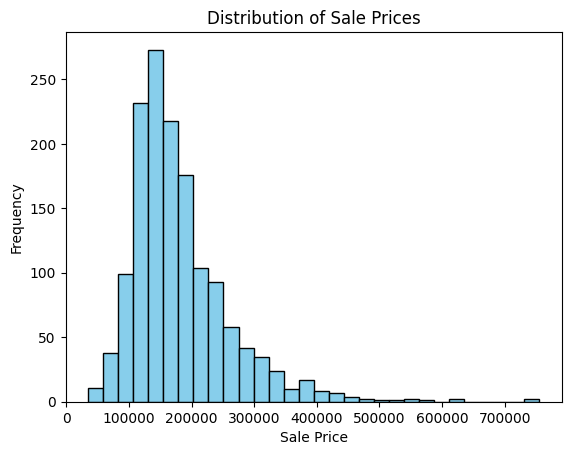

Here is the histogram showing the distribution of sale prices in the dataset.

> Finished chain.


In [24]:
response = agent_executor.invoke("주택가격 분포를 히스토그램으로 나타내줘.") # 행과 열의 수를 묻는 질문

In [25]:
response

{'input': '주택가격 분포를 히스토그램으로 나타내줘.',
 'output': 'Here is the histogram showing the distribution of sale prices in the dataset.'}

In [26]:
llm_model = ChatOpenAI(
    model="gpt-3.5-turbo-0125",  # OpenAI GPT-4o 모델 사용
    temperature=0,
    openai_api_key=OPENAI_API_KEY,
)

agent_executor = create_pandas_dataframe_agent(
    llm_model,
    train,
    agent_type="openai-tools", # OpenAI Tools 에이전트 사용
    verbose=True, # 로그 출력
    return_intermediate_steps=True,
    allow_dangerous_code=True, # 위험한 코드 실행 허용 (필수)
)



> Entering new AgentExecutor chain...


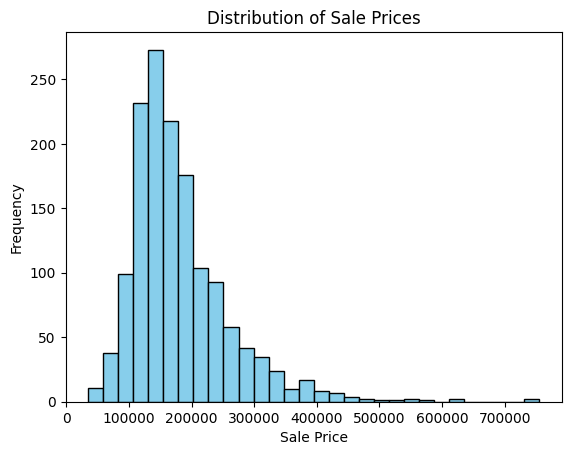


Invoking: `python_repl_ast` with `{'query': "import matplotlib.pyplot as plt\n\nplt.hist(df['SalePrice'], bins=30, color='skyblue', edgecolor='black')\nplt.xlabel('Sale Price')\nplt.ylabel('Frequency')\nplt.title('Distribution of Sale Prices')\nplt.show()"}`


Here is the histogram showing the distribution of sale prices in the dataset.

> Finished chain.


In [27]:
response = agent_executor.invoke("주택가격 분포를 히스토그램으로 나타내줘.") # 행과 열의 수를 묻는 질문

In [28]:
response  # 응답 결과 확인

{'input': '주택가격 분포를 히스토그램으로 나타내줘.',
 'output': 'Here is the histogram showing the distribution of sale prices in the dataset.',
 'intermediate_steps': [(ToolAgentAction(tool='python_repl_ast', tool_input={'query': "import matplotlib.pyplot as plt\n\nplt.hist(df['SalePrice'], bins=30, color='skyblue', edgecolor='black')\nplt.xlabel('Sale Price')\nplt.ylabel('Frequency')\nplt.title('Distribution of Sale Prices')\nplt.show()"}, log='\nInvoking: `python_repl_ast` with `{\'query\': "import matplotlib.pyplot as plt\\n\\nplt.hist(df[\'SalePrice\'], bins=30, color=\'skyblue\', edgecolor=\'black\')\\nplt.xlabel(\'Sale Price\')\\nplt.ylabel(\'Frequency\')\\nplt.title(\'Distribution of Sale Prices\')\\nplt.show()"}`\n\n\n', message_log=[AIMessageChunk(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_Nna5Vt9pWiMkaOGrevyOQt5d', 'function': {'arguments': '{"query":"import matplotlib.pyplot as plt\\n\\nplt.hist(df[\'SalePrice\'], bins=30, color=\'skyblue\', edgecolor=\'black\')\

In [30]:
intermediate_actions = response['intermediate_steps'] # 중간 단계 액션 확인
intermediate_actions
len(intermediate_actions)  # 중간 단계 액션의 개수 확인

1

In [35]:
python_code = intermediate_actions[0][0].tool_input['query']  # 에이전트가 실행한 코드 확인
python_code

"import matplotlib.pyplot as plt\n\nplt.hist(df['SalePrice'], bins=30, color='skyblue', edgecolor='black')\nplt.xlabel('Sale Price')\nplt.ylabel('Frequency')\nplt.title('Distribution of Sale Prices')\nplt.show()"

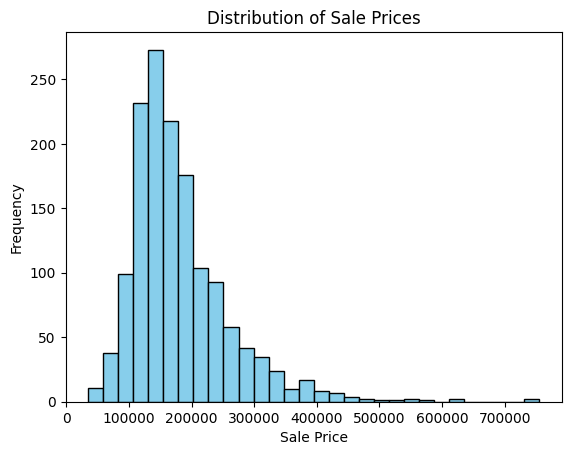

In [36]:
df = train.copy()  # 데이터프레임 복사
exec(python_code)  # 에이전트가 실행한 코드를 실행하여 결과 확인